# Visual ISAM Example

Every optimizer used so far has solved its problem in one shot: build the whole graph, then call `optimize()` once. Real robots don't get to wait until the end of the mission to know where they are -- measurements arrive continuously, and the estimate has to update *incrementally*.

This notebook is a first taste of that: a structure-from-motion problem where 8 cameras orbit a 10-meter cube of landmarks, always facing the center. As each new camera pose and its landmark observations arrive, we feed them to `NonlinearISAM`, which relinearizes and reorders the problem every few updates instead of resolving from scratch -- the classic "incremental SLAM" pattern.

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/VisualISAMExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import gtsam
import gtsam.utils.plot as gtsam_plot
from gtsam.examples import SFMdata
from gtsam import (Cal3_S2, GenericProjectionFactorCal3_S2,
                    NonlinearFactorGraph, NonlinearISAM, Pose3,
                    PriorFactorPoint3, PriorFactorPose3, Rot3,
                    PinholeCameraCal3_S2, Values, Point3)
from gtsam.symbol_shorthand import X, L

## 1. Camera and scene setup

The scene comes from the shared `SFMdata` helper module: 8 ground-truth landmarks forming a 10-meter cube, and 8 ground-truth camera poses circling it. `K` is a simple pinhole calibration, and `camera_noise` models about one pixel of measurement noise.

In [3]:
# Define the camera calibration parameters
K = Cal3_S2(50.0, 50.0, 0.0, 50.0, 50.0)

# Define the camera observation noise model
camera_noise = gtsam.noiseModel.Isotropic.Sigma(2, 1.0)  # one pixel in u and v

# Create the set of ground-truth landmarks
points = SFMdata.createPoints()
# Create the set of ground-truth poses
poses = SFMdata.createPoses()

## 2. Set up incremental ISAM

`NonlinearISAM(reorderInterval=3)` relinearizes and reorders the variables every 3 updates, rather than on every single one -- a tradeoff between staying close to the true nonlinear solution and not paying the reordering cost too often.

In [4]:
isam = NonlinearISAM(reorderInterval=3)

graph = NonlinearFactorGraph()
initial_estimate = Values()

## 3. Feed observations incrementally

For each camera pose, we project every landmark into the image to get a (simulated) pixel measurement, and add a `GenericProjectionFactorCal3_S2` per observation. The initial guesses -- for both poses and landmarks -- are deliberately perturbed away from ground truth.

The first frame is special: since iSAM needs each landmark observed at least twice before it becomes well constrained, we don't call `isam.update()` yet. Instead we add priors on pose `x0` (to fix the coordinate frame) and landmark `l0` (to fix the scale), plus initial guesses for every landmark. From frame 1 onward, each new pose's factors are handed to `isam.update()`, and we read back the current estimate.

In [5]:
# Loop over the different poses, adding the observations to iSAM incrementally
for i, pose in enumerate(poses):
    camera = PinholeCameraCal3_S2(pose, K)
    # Add factors for each landmark observation
    for j, point in enumerate(points):
        measurement = camera.project(point)
        factor = GenericProjectionFactorCal3_S2(
            measurement, camera_noise, X(i), L(j), K)
        graph.push_back(factor)

    # Intentionally initialize the variables off from the ground truth
    noise = Pose3(r=Rot3.Rodrigues(-0.1, 0.2, 0.25),
                  t=Point3(0.05, -0.10, 0.20))
    initial_xi = pose.compose(noise)

    # Add an initial guess for the current pose
    initial_estimate.insert(X(i), initial_xi)

    # If this is the first iteration, add a prior on the first pose to set the coordinate frame
    # and a prior on the first landmark to set the scale
    # Also, as iSAM solves incrementally, we must wait until each is observed at least twice before
    # adding it to iSAM.
    if i == 0:
        # Add a prior on pose x0, with 0.3 rad std on roll,pitch,yaw and 0.1m x,y,z
        pose_noise = gtsam.noiseModel.Diagonal.Sigmas(
            np.array([0.3, 0.3, 0.3, 0.1, 0.1, 0.1]))
        factor = PriorFactorPose3(X(0), poses[0], pose_noise)
        graph.push_back(factor)

        # Add a prior on landmark l0
        point_noise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)
        factor = PriorFactorPoint3(L(0), points[0], point_noise)
        graph.push_back(factor)

        # Add initial guesses to all observed landmarks
        noise = np.array([-0.25, 0.20, 0.15])
        for j, point in enumerate(points):
            # Intentionally initialize the variables off from the ground truth
            initial_lj = points[j] + noise
            initial_estimate.insert(L(j), initial_lj)
    else:
        # Update iSAM with the new factors
        isam.update(graph, initial_estimate)
        current_estimate = isam.estimate()
        print('*' * 50)
        print('Frame {}:'.format(i))
        current_estimate.print('Current estimate: ')

        # Clear the factor graph and values for the next iteration
        graph.resize(0)
        initial_estimate.clear()

**************************************************
Frame 1:
Current estimate: 
Values with 10 values:
Value l0: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	9.99996;
	9.99995;
	9.99998
]



Value l1: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-12.8291;
	10.3572;
	10.376
]



Value l2: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-12.4628;
	-11.5675;
	10.3645
]



Value l3: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	9.98338;
	-11.2238;
	9.85452
]



Value l4: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	9.49906;
	9.94737;
	-10.8915
]


...


Value x3: (gtsam::Pose3)
R: [
	-0.703393, 0.0119506, 0.710701;
	-0.710741, 0.00120685, -0.703453;
	-0.00926438, -0.999928, 0.00764487
]
t:  -21.2646   21.0034 -0.170016



Value x4: (gtsam::Pose3)
R: [
	0.00720172, 0.0103087, 0.999921;
	-0.99993, 0.00946178, 0.00710424;
	-0.00938779, -0.999902, 0.0103761
]
t:  -29.8864 -0.275862 -0.165907



Value x5: (gtsam::Pose3)
R: [
	0.707702, -0.00881747, 0.706456;
	-0.706511, -0.00787646, 0.707658;
	-0.000675385, -0.99993, -0.0118038
]
t: -21.0699  -21.143 0.554305



Value x6: (gtsam::Pose3)
R: [
	0.999971, -0.00599312, 0.00476305;
	-0.00479728, -0.00571087, 0.999972;
	-0.00596575, -0.999966, -0.00573945
]
t: 0.436101 -29.7856 0.775382



Value x7: (gtsam::Pose3)
R: [
	0.711029, -0.0250445, -0.702716;
	0.703032, 0.0061032, 0.711132;
	-0.0135212, -0.999668, 0.0219467
]
t:   21.3687  -20.7842 -0.133853


## 4. Visualize the final estimate

The printed `Values` above are hard to picture -- 8 poses and 8 landmarks as raw numbers. Plotting the final iSAM estimate in 3D shows the payoff directly: the recovered landmarks should form roughly a cube, and the recovered camera poses should trace out roughly a circle around it, despite every pose and landmark having started from a deliberately wrong initial guess.

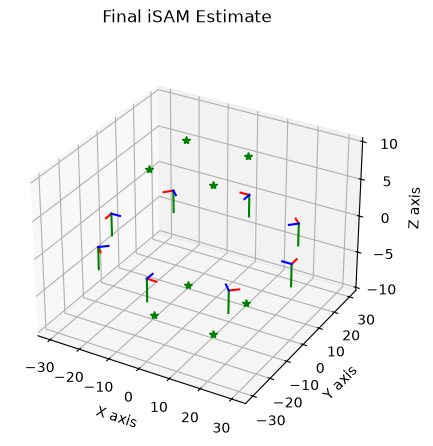

In [6]:
gtsam_plot.plot_3d_points(0, current_estimate, linespec="g*", title="Final iSAM Estimate")
for i in range(len(poses)):
    if current_estimate.exists(X(i)):
        gtsam_plot.plot_pose3(0, current_estimate.atPose3(X(i)), axis_length=3)
plt.show()

This is exactly the kind of incremental estimation problem `NonlinearISAM` was built for -- and it's the direct predecessor to `ISAM2`, GTSAM's more efficient incremental solver, used in the companion `VisualISAM2Example` notebook.